# ColGraphRAG MultiModalQA (MMQA) — 단계별 파이프라인 튜토리얼

이 노트북은 MultiModalQA 코퍼스에서 질의 기반 멀티모달 GraphRAG 파이프라인을 따라갑니다(WebQA 튜토리얼과 대응).

| 단계 | 스크립트 | 역할 |
|-------|--------|------|
| 0 | `export_mmqa_slice.py` | `data/multimodalqa/dataset/`의 `MMQA_*_n*.jsonl`을 `result/<RUN_ID>/mmqa_slice/`로 정규화·복사 |
| 2 | `pattern.py` | 질문별 그래프 패턴 (LLM) |
| 3 | `extraction.py` | 엔티티·관계 추출 (LLM) |
| 4 | `construct.py` | NetworkX → GraphML |
| 5 | `inference.py` | ColEmbed MaxSim 검색 + Gemma 답변 (`MMGRAPHRAG_DATASET=mmqa`) |
| 6 | `eval/evaluate_multimodal_qa.py` | 리스트형 EM/F1 등(MMQA는 `metadata.modalities`로 층화 가능) |

**`mmqa_slice`의 slice:** MMQA 질문·텍스트·이미지·테이블 JSONL을 한 run에서 쓰도록 `result/<RUN_ID>/mmqa_slice/` 아래 표준 파일명으로 정리한 **실행용 데이터 번들**을 뜻합니다. Tensor slice나 논문에서 별도로 정의한 개념이 아닙니다. 0단계가 `data/multimodalqa/dataset/`의 `MMQA_*_n*.jsonl`을 읽어 `mmqa_questions.jsonl` 등으로 만듭니다. (`N_QUERIES` 등은 slice 정의가 아니라 이후 단계에서 처리할 질문 수를 제한하는 **실행 설정**입니다.)

사전 준비: WebQA 튜토리얼과 같이 venv + `pip install -r requirements.txt`, 그리고 `util/download_models.py`로 HF 가중치입니다. Ollama 가중치는 선택적으로 아래 Ollama 모델 다운로드 절에서 받습니다. 실 Gemma는 CUDA GPU가 필요합니다. 배선만 확인하려면 통합 실행 셀에서 `--dry-run`을 켭니다.

데이터: 저장소에 포함된 dev 토이 번들(`MMQA_*_n100.jsonl` 등)이 `config/data.yaml`의 `multimodalqa.data_dir` 기본 경로에 있어야 합니다. 이미지 파일은 보통 `data/multimodalqa/final_dataset_images/`입니다(`MMQA_images*.jsonl`의 `path` 파일명 기준).

실행 ID: MMQA는 `MMGRAPHRAG_RUN_ID=multimodalqa/...` 형태를 씁니다. 결과는 `result/multimodalqa/<하위폴더>/`에 모입니다.

두 가지 방식: 한 번에 실행(End-to-end)(`tests/test_pipeline.py --dataset mmqa`) 또는 단계별 수동. 같은 세션에서 서로 다른 `RUN_ID`를 섞지 마세요.

## 가상환경과 CUDA 의존성

WebQA MMQA 공통입니다. 저장소 루트에서 venv를 만들고 `requirements.txt`를 설치합니다.

리눅스에서 가상환경 생성·활성화 예시(저장소 루트에서):

```bash
python3 -m venv .venv
source .venv/bin/activate
pip install -U pip
pip install -r requirements.txt
```

비활성화: `deactivate`

Jupyter 커널 예시(가상환경 **활성화 후**):

```bash
pip install ipykernel
python -m ipykernel install --user --name colgraphrag-mmqa --display-name "Python (colgraphrag_mmqa)"
```

CUDA PyTorch 및 나머지 패키지는 WebQA 튜토리얼(`colgraphrag_webqa_pipeline_tutorial_kor.ipynb`)의 가상환경 절을 그대로 따르면 됩니다.

---

In [1]:
import shutil
import subprocess

nv = shutil.which("nvidia-smi")
if nv:
    r = subprocess.run(
        [
            nv,
            "--query-gpu=index,name,driver_version,memory.total,memory.used,memory.free",
            "--format=csv,noheader",
        ],
        capture_output=True,
        text=True,
        timeout=15,
    )
    if r.returncode == 0:
        print("nvidia-smi (GPU 목록):\n")
        print(r.stdout.strip() or "(비어 있음)")
    else:
        print("nvidia-smi 실패:", r.stderr)
else:
    print("PATH에 nvidia-smi 없음 — NVIDIA CLI가 없거나 GPU 머신이 아님.")

print()

try:
    import torch
except ImportError:
    print("torch: 아직 설치되지 않음 — 먼저 pip install -r requirements.txt를 완료하세요.")
else:
    print("torch:", torch.__version__)
    print("torch.cuda.is_available():", torch.cuda.is_available())
    if torch.cuda.is_available():
        n = torch.cuda.device_count()
        print("torch.cuda.device_count():", n)
        for i in range(n):
            print(f"  [{i}]", torch.cuda.get_device_name(i))
            print("      할당된 메모리 MB:", torch.cuda.memory_allocated(i) / 1e6)

nvidia-smi (GPU 목록):

0, NVIDIA RTX A6000, 570.195.03, 49140 MiB, 15710 MiB, 32841 MiB



torch: 2.6.0+cu124
torch.cuda.is_available(): True
torch.cuda.device_count(): 1
  [0] NVIDIA RTX A6000
      할당된 메모리 MB: 0.0


## 저장소 루트와 경로 맞추기

파이프라인은 `PYTHONPATH`에 저장소 루트가 들어가야 합니다.

In [2]:
import os
import sys
from pathlib import Path

_here = Path.cwd()
REPO = None
for _p in [_here, *list(_here.resolve().parents)]:
    if (_p / "inference.py").is_file():
        REPO = _p
        break
if REPO is None:
    raise RuntimeError(
        "저장소 루트(inference.py가 있는 폴더)를 찾을 수 없습니다. "
        "Jupyter cwd를 프로젝트 루트로 맞추거나 해당 폴더로 cd한 뒤 이 셀을 다시 실행하세요."
    )

assert (REPO / "inference.py").is_file(), f"REPO를 저장소 루트로 맞추세요; 현재 {REPO}"

os.chdir(REPO)
sys.path.insert(0, str(REPO))

print("REPO =", REPO.resolve())
print("cwd =", Path.cwd())

REPO = /workspace/late-interaction-mm-graph-rag
cwd = /workspace/late-interaction-mm-graph-rag


## 프로젝트 `.venv`와 Jupyter 커널

저장소 루트의 `.venv`(예: `python -m venv .venv` 후 `pip install -r requirements.txt`)와 **현재 노트북 커널의 Python**이 같아야 패키지·CUDA 휠 버전이 어긋나지 않습니다. 아래 셀에서 경로 일치 여부와 `pip check`를 확인합니다.

In [3]:
import subprocess
import sys
from pathlib import Path

if "REPO" not in globals():
    raise RuntimeError("먼저 REPO를 정의하는 셀(저장소 루트와 경로 맞추기)을 실행하세요.")

_cur = Path(sys.executable).resolve()
_venv_py = (REPO / ".venv" / "bin" / "python").resolve()

print("sys.executable:", _cur)
print("REPO/.venv/bin/python:", _venv_py)

if _venv_py.is_file():
    if _cur == _venv_py:
        print("\n커널이 프로젝트 .venv와 일치합니다.")
    else:
        print(
            "\n경고: 커널이 프로젝트 .venv가 아닙니다. "
            "이 venv에 ipykernel을 설치·등록한 뒤 해당 커널을 선택하세요."
        )
else:
    print(
        "\n프로젝트에 .venv/bin/python이 없습니다. "
        "저장소 루트에서 python -m venv .venv 후 requirements를 설치하세요."
    )

_cfg = REPO / ".venv" / "pyvenv.cfg"
if _cfg.is_file():
    print("\n--- pyvenv.cfg (앞부분) ---")
    for line in _cfg.read_text(encoding="utf-8", errors="replace").splitlines()[:8]:
        print(line)

_rc = subprocess.run(
    [str(_cur), "-m", "pip", "check"],
    capture_output=True,
    text=True,
    timeout=120,
)
print("\n--- pip check ---")
print(_rc.stdout.strip() or "(stdout 비어 있음)")
if _rc.stderr.strip():
    print(_rc.stderr.strip())
print("exit:", _rc.returncode)

sys.executable: /usr/bin/python3.11
REPO/.venv/bin/python: /usr/bin/python3.11

커널이 프로젝트 .venv와 일치합니다.

--- pyvenv.cfg (앞부분) ---
home = /usr/bin
include-system-site-packages = false
version = 3.11.10
executable = /usr/bin/python3.11
command = /usr/bin/python3 -m venv /workspace/late-interaction-mm-graph-rag/.venv

--- pip check ---
pygobject 3.42.1 requires pycairo, which is not installed.
exit: 1


## 환경 확인(선택)

실추론에서는 VRAM을 줄이려고 `GEMMA4_E4B_IT_TORCH_DTYPE=bf16`을 권장합니다.

In [4]:
import torch

print("torch:", torch.__version__)
print("CUDA 사용 가능:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("디바이스:", torch.cuda.get_device_name(0))

torch: 2.6.0+cu124
CUDA 사용 가능: True
디바이스: NVIDIA RTX A6000


## 설정 파일

- `config/data.yaml` — `multimodalqa.data_dir`, `multimodalqa.images_dir` 등.
- `config/model.yaml` — Gemma, ColEmbed 경로.

필요 시 `.env`에 `HF_TOKEN`을 둡니다.

In [5]:
from pathlib import Path

_cfgs = [REPO / "config/data.yaml", REPO / "config/model.yaml"]
_ok = 0
for p in _cfgs:
    ex = p.is_file()
    if ex:
        _ok += 1
    print(p.name, "있음:" if ex else "없음:", p)
print("설정 파일 준비:", f"{_ok}/{len(_cfgs)}")

data.yaml 있음: /workspace/late-interaction-mm-graph-rag/config/data.yaml
model.yaml 있음: /workspace/late-interaction-mm-graph-rag/config/model.yaml
설정 파일 준비: 2/2


## Hugging Face 모델 다운로드

WebQA 튜토리얼과 동일: `util/download_models.py`로 Gemma·ColEmbed를 `models/`에 받습니다. 다운로드 다음 셀에서 `config/model.yaml` 기준 경로와 폴더 합계 용량(GiB/MiB)을 확인합니다.

Ollama(예: `config/model.yaml`의 `gemma4:e2b`)는 `models/`가 아니라 Ollama 기본 디렉터리에 둡니다. 아래 Ollama 모델 다운로드 절을 따르세요.

In [ ]:
import os
import subprocess
import sys
from pathlib import Path

try:
    _r = REPO
except NameError:
    _here = Path.cwd()
    _r = _here if (_here / "util" / "download_models.py").is_file() else _here.parent

dl = _r / "util" / "download_models.py"
if not dl.is_file():
    raise FileNotFoundError(f"Missing {dl}")

print("=== Hugging Face 체크포인트 다운로드 (실행) ===")
print("스크립트: util/download_models.py")
print("대상: gemma, colembed")
print("게이트 모델은 `.env`의 HF_TOKEN이 필요할 수 있습니다.\n")

_dl_env = {**os.environ, "PYTHONUNBUFFERED": "1"}
_rc_dl = subprocess.run(
    [sys.executable, "-u", str(dl), "--only", "gemma", "colembed"],
    cwd=str(_r),
    env=_dl_env,
    check=False,
)
print("\n다운로드 프로세스 종료 코드:", _rc_dl.returncode)

In [5]:
from pathlib import Path

try:
    import yaml
except ImportError:
    raise SystemExit("PyYAML 필요: pip install PyYAML")

try:
    _repo = REPO
except NameError:
    _here = Path.cwd()
    _repo = _here if (_here / "config" / "model.yaml").is_file() else _here.parent


def _resolve_under_repo(rel_or_abs: str | Path, repo: Path) -> Path:
    p = Path(rel_or_abs).expanduser()
    return p.resolve() if p.is_absolute() else (repo / p).resolve()


def _dir_bytes(p: Path) -> int:
    if not p.is_dir():
        return 0
    n = 0
    for f in p.rglob("*"):
        if f.is_file():
            try:
                n += f.stat().st_size
            except OSError:
                pass
    return n


def _fmt_size(b: int) -> str:
    gib = b / (1024**3)
    mib = b / (1024**2)
    if gib >= 1:
        return f"{gib:.2f} GiB ({b:,} bytes)"
    return f"{mib:.2f} MiB ({b:,} bytes)"


_cfg_path = _repo / "config" / "model.yaml"
with _cfg_path.open(encoding="utf-8") as f:
    cfg = yaml.safe_load(f) or {}

print("=== HF 체크포인트 경로 · 용량(GiB/MiB) ===")
print("설정 파일:", _cfg_path.resolve())
print()

_gem = cfg.get("gemma") or {}
_col = cfg.get("colembed") or {}

_g_path = (_gem.get("e4b_it_path") or "").strip()
_g_repo = (_gem.get("hf_repo_id") or "").strip()
if _g_path:
    gp = _resolve_under_repo(_g_path, _repo)
    g_ok = gp.is_dir()
    g_sz = _dir_bytes(gp) if g_ok else 0
    print("[Gemma]")
    print("  hf_repo_id:", _g_repo or "(없음)")
    print("  경로:", gp)
    print("  존재:", g_ok, "| 합계:", _fmt_size(g_sz) if g_ok else "(폴더 없음)")
else:
    print("[Gemma] model.yaml에 e4b_it_path 없음")

_c_path = (_col.get("model_path") or "").strip()
_c_id = (_col.get("model_id") or "").strip() or (_col.get("hf_repo_id") or "").strip()
if _c_path:
    cp = _resolve_under_repo(_c_path, _repo)
    c_ok = cp.is_dir()
    c_sz = _dir_bytes(cp) if c_ok else 0
    print()
    print("[ColEmbed]")
    print("  model_id / hf_repo_id:", _c_id or "(없음)")
    print("  경로:", cp)
    print("  존재:", c_ok, "| 합계:", _fmt_size(c_sz) if c_ok else "(폴더 없음)")
else:
    print()
    print("[ColEmbed] model.yaml에 model_path 없음")

print()
print("용량은 해당 폴더 트리 안의 일반 파일 크기 합입니다(.safetensors 등).")

=== HF 체크포인트 경로 · 용량(GiB/MiB) ===
설정 파일: /workspace/late-interaction-mm-graph-rag/config/model.yaml

[Gemma]
  hf_repo_id: google/gemma-4-E4B-it
  경로: /workspace/late-interaction-mm-graph-rag/models/mllm/gemma-4-E4B-it
  존재: True | 합계: 14.92 GiB (16,024,820,880 bytes)

[ColEmbed]
  model_id / hf_repo_id: nvidia/llama-nemotron-colembed-vl-3b-v2
  경로: /workspace/late-interaction-mm-graph-rag/models/retriever/llama-nemotron-colembed-vl-3b-v2
  존재: True | 합계: 8.22 GiB (8,828,542,203 bytes)

용량은 해당 폴더 트리 안의 일반 파일 크기 합입니다(.safetensors 등).


## Ollama 모델 다운로드 (선택)

`config/model.yaml`의 `ollama.model`(예: `gemma4:e2b`)을 Ollama에 받습니다. 가중치는 `models/`가 아니라 Ollama 기본 저장소(보통 `~/.ollama`)에 둡니다. 다른 루트는 환경 변수 `OLLAMA_MODELS`로 지정합니다.

`ollama pull`은 실행 중인 Ollama 서버가 있어야 합니다. `could not connect to ollama server`가 뜨면 Ollama 서버 단락부터 순서대로 실행하세요.

### Ollama 서버 (`ollama serve`)

서버 주소는 기본 `127.0.0.1:11434` 입니다. **`PATH`에 `ollama` CLI가 없으면** 바로 아래 코드 셀(설치·PATH 보강)을 먼저 실행한 뒤, 그 다음 셀에서 백그라운드 `ollama serve`를 띄우세요. 터미널에서 이미 `ollama serve`를 켜 두었다면 설치 셀은 생략해도 됩니다(서버 셀이 이미 응답 중이면 건너뜀).

In [2]:
import os
import platform
import shutil
import subprocess

# 다음 셀(`ollama serve`)이 `shutil.which("ollama")`로 찾을 수 있도록 PATH를 보강합니다.
_HOME = os.path.expanduser("~")
for _dir in ("/usr/local/bin", "/usr/bin", os.path.join(_HOME, ".local", "bin")):
    if _dir and os.path.isdir(_dir):
        _path = os.environ.get("PATH", "")
        if _dir not in _path.split(os.pathsep):
            os.environ["PATH"] = _dir + os.pathsep + _path if _path else _dir

# 설치만 되어 있고 노트북 세션 PATH에 없는 경우
for _cand in (
    "/usr/local/bin/ollama",
    "/usr/bin/ollama",
    os.path.join(_HOME, ".local", "bin", "ollama"),
):
    if os.path.isfile(_cand) and os.access(_cand, os.X_OK):
        _d = os.path.dirname(_cand)
        _path = os.environ.get("PATH", "")
        if _d not in _path.split(os.pathsep):
            os.environ["PATH"] = _d + os.pathsep + _path if _path else _d
        break

if shutil.which("ollama"):
    print("ollama CLI 확인:", shutil.which("ollama"))
else:
    _sys = platform.system()
    if _sys == "Linux":
        print("PATH에 ollama가 없어 공식 Linux 설치 스크립트를 실행합니다.")
        print("(네트워크 필요) https://ollama.com/download/linux")
        if not shutil.which("zstd"):
            print("Ollama 설치에 zstd가 필요합니다. apt/dnf/pacman으로 설치를 시도합니다…")
            _z = subprocess.run(
                [
                    "bash",
                    "-c",
                    "command -v zstd >/dev/null 2>&1 && exit 0; "
                    "if command -v apt-get >/dev/null 2>&1; then apt-get update -qq && apt-get install -y -qq zstd; "
                    "elif command -v dnf >/dev/null 2>&1; then dnf install -y zstd; "
                    "elif command -v pacman >/dev/null 2>&1; then pacman -S --noconfirm zstd; "
                    "else exit 1; fi",
                ],
            )
            if _z.returncode != 0 or not shutil.which("zstd"):
                raise RuntimeError(
                    "zstd가 없어 Ollama 설치 스크립트를 실행할 수 없습니다. 터미널에서 설치 후 이 셀을 다시 실행하세요.\n"
                    "  Debian/Ubuntu: sudo apt-get install zstd\n"
                    "  Fedora/RHEL:    sudo dnf install zstd\n"
                    "  Arch:           sudo pacman -S zstd"
                )
        _rc = subprocess.run(
            ["bash", "-c", "curl -fsSL https://ollama.com/install.sh | sh"],
        )
        if _rc.returncode != 0:
            raise RuntimeError(
                "Ollama 자동 설치가 실패했습니다. zstd·curl 설치와 네트워크를 확인한 뒤 터미널에서:\n"
                "  curl -fsSL https://ollama.com/install.sh | sh\n"
                "완료 후 Jupyter 커널을 재시작하거나 `which ollama` 경로를 확인하세요."
            )
        for _dir in ("/usr/local/bin", "/usr/bin", os.path.join(_HOME, ".local", "bin")):
            if _dir and os.path.isdir(_dir):
                _path = os.environ.get("PATH", "")
                if _dir not in _path.split(os.pathsep):
                    os.environ["PATH"] = _dir + os.pathsep + _path if _path else _dir
        _rv = subprocess.run(
            ["bash", "-lc", "command -v ollama"],
            capture_output=True,
            text=True,
        )
        if _rv.returncode == 0:
            _op = _rv.stdout.strip()
            if _op:
                _od = os.path.dirname(_op)
                _path = os.environ.get("PATH", "")
                if _od not in _path.split(os.pathsep):
                    os.environ["PATH"] = _od + os.pathsep + _path if _path else _od
        if not shutil.which("ollama"):
            raise RuntimeError(
                "설치는 끝났지만 이 세션에서 ollama를 찾지 못했습니다. "
                "커널 재시작 후 이 셀과 다음 셀을 다시 실행하거나, 터미널에서 `which ollama`로 경로를 확인하세요."
            )
        print("설치 후 ollama CLI:", shutil.which("ollama"))
    elif _sys == "Darwin":
        raise RuntimeError(
            "macOS: https://ollama.com/download 에서 설치하거나 `brew install ollama` 후 "
            "커널을 재시작하고 이 셀을 다시 실행하세요."
        )
    else:
        raise RuntimeError(
            "https://ollama.com 에서 OS에 맞게 설치한 뒤 커널을 재시작하고 이 셀을 다시 실행하세요."
        )


PATH에 ollama가 없어 공식 Linux 설치 스크립트를 실행합니다.
(네트워크 필요) https://ollama.com/download/linux
Ollama 설치에 zstd가 필요합니다. apt/dnf/pacman으로 설치를 시도합니다…


debconf: delaying package configuration, since apt-utils is not installed


Selecting previously unselected package zstd.
(Reading database ... 24135 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...


>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
#######################################################################   99.6%

설치 후 ollama CLI: /usr/local/bin/ollama


######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [4]:
import os
import shutil
import socket
import subprocess
import time

_CONNECT_HOST = os.getenv("OLLAMA_CONNECT_HOST", "127.0.0.1").strip() or "127.0.0.1"
_CONNECT_PORT = int((os.getenv("OLLAMA_PORT", "11434") or "11434").strip())


def _ollama_tcp_up(host: str, port: int, timeout: float = 2.0) -> bool:
    try:
        with socket.create_connection((host, port), timeout=timeout):
            return True
    except OSError:
        return False


if _ollama_tcp_up(_CONNECT_HOST, _CONNECT_PORT):
    print(f"Ollama 서버 이미 응답 중: {_CONNECT_HOST}:{_CONNECT_PORT}")
else:
    exe = shutil.which("ollama")
    if not exe:
        raise RuntimeError("PATH에 ollama CLI가 없습니다. https://ollama.com 에서 설치하세요.")

    prev = globals().get("OLLAMA_SERVER_PROC")
    if isinstance(prev, subprocess.Popen) and prev.poll() is None:
        print("OLLAMA_SERVER_PROC가 이미 떠 있음(PID {}). 연결 재시도…".format(prev.pid))
    else:
        print(f"백그라운드 시작: `{exe} serve` (접속 확인: {_CONNECT_HOST}:{_CONNECT_PORT}) …")
        out = subprocess.DEVNULL
        globals()["OLLAMA_SERVER_PROC"] = subprocess.Popen(
            [exe, "serve"],
            stdout=out,
            stderr=out,
            start_new_session=True,
        )
        print("PID:", globals()["OLLAMA_SERVER_PROC"].pid)

    for i in range(45):
        time.sleep(1)
        if _ollama_tcp_up(_CONNECT_HOST, _CONNECT_PORT):
            print(f"연결 OK — {_CONNECT_HOST}:{_CONNECT_PORT} (약 {i + 1}s)")
            break
    else:
        raise RuntimeError(
            f"{_CONNECT_HOST}:{_CONNECT_PORT} 에 연결할 수 없습니다. "
            "터미널에서 `ollama serve` 로그를 확인하거나 OLLAMA_PORT/방화벽을 점검하세요."
        )

백그라운드 시작: `/usr/local/bin/ollama serve` (접속 확인: 127.0.0.1:11434) …
PID: 11317


연결 OK — 127.0.0.1:11434 (약 1s)


In [6]:
# -----------------------------------------------------------------------------
# 역할: Ollama 모델 다운로드(pull) 실행
# - config/model.yaml 의 ollama.model 과 util/download_models.py 가 사용할 태그를 맞춥니다.
# - 본 셀은 레포 안 models/ 가 아니라 Ollama 기본 저장소(보통 ~/.ollama, 또는 OLLAMA_MODELS)
#   에 가중치를 받습니다.
# - 앞쪽에서 ollama serve 가 떠 있어야 pull/런타임이 정상입니다.
# -----------------------------------------------------------------------------

import os
import subprocess
import sys
from pathlib import Path

try:
    _r = REPO
except NameError:
    _here = Path.cwd()
    _r = _here if (_here / "util" / "download_models.py").is_file() else _here.parent

dl = _r / "util" / "download_models.py"
if not dl.is_file():
    raise FileNotFoundError(f"Missing {dl}")

print("=== Ollama pull (실행) ===")
print("명령: python util/download_models.py --only ollama")
print("저장 위치: Ollama 기본 디렉터리(보통 ~/.ollama). repo models/ 아님.\n")

_dl_env = {**os.environ, "PYTHONUNBUFFERED": "1"}
_rc = subprocess.run(
    [sys.executable, "-u", str(dl), "--only", "ollama"],
    cwd=str(_r),
    env=_dl_env,
    check=False,
)
print("\n종료 코드:", _rc.returncode)

=== Ollama pull (실행) ===
명령: python util/download_models.py --only ollama
저장 위치: Ollama 기본 디렉터리(보통 ~/.ollama). repo models/ 아님.



--- ollama (default ~/.ollama store): gemma4:e2b
(Using Ollama default model directory; not writing under repo models/.)


pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest 
pulling 4e30e2665218:   0% ▕                  ▏  29 MB/7.2 GB                  pulling manifest 
pulling 4e30e2665218:   1% ▕                  ▏  80 MB/7.2 GB                  pulling manifest 
pulling 4e30e2665218:   2% ▕                  ▏ 132 MB/7.2 GB                  pulling manifest 
pulling 4e30e2665218:   3% ▕                  ▏ 200 MB/7.2 GB                  pulling manifest 
pulling 4e30e2665218:   3% ▕                  ▏ 226 MB/7.2 GB                  pulling manifest 
pulling 4e30e2665218:   4% ▕                  ▏ 269 MB/7.2 GB                  pulling manifest 
pulling 4e30e2665218:   5% ▕                  ▏ 333 MB/7.2 GB                  pulling manifest 
pulling 4e30e2665218:   5% ▕                  ▏ 365 MB/7.2 GB                  pulling manifes

Done: ollama pull gemma4:e2b
--- ollama (default ~/.ollama store): gemma4:e4b
(Using Ollama default model directory; not writing under repo models/.)


pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest 
pulling 4c27e0f5b5ad:   0% ▕                  ▏ 1.7 MB/9.6 GB                  pulling manifest 
pulling 4c27e0f5b5ad:   1% ▕                  ▏  68 MB/9.6 GB                  pulling manifest 
pulling 4c27e0f5b5ad:   1% ▕                  ▏ 128 MB/9.6 GB                  pulling manifest 
pulling 4c27e0f5b5ad:   2% ▕                  ▏ 160 MB/9.6 GB                  pulling manifest 
pulling 4c27e0f5b5ad:   2% ▕                  ▏ 207 MB/9.6 GB                  pulling manifest 
pulling 4c27e0f5b5ad:   3% ▕                  ▏ 273 MB/9.6 GB                  pulling manifest 
pulling 4c27e0f5b5ad:   3% ▕                  ▏ 302 MB/9.6 GB                  pulling manifest 
pulling 4c27e0f5b5ad:   4% ▕                  ▏ 348 MB/9.6 GB                  pulling manifes

Done: ollama pull gemma4:e4b

Example environment overrides (local snapshots under models/):
  GEMMA4_E4B_IT_MODEL_PATH=/workspace/late-interaction-mm-graph-rag/models/mllm/gemma-4-E4B-it
  COLEMBED_MODEL_PATH=/workspace/late-interaction-mm-graph-rag/models/retriever/llama-nemotron-colembed-vl-3b-v2
  WEBQA_FLUENCY_MODEL=/workspace/late-interaction-mm-graph-rag/models/eval/bart-large-cnn

Ollama model 'gemma4:e2b': stored under the default Ollama directory (/root/.ollama), not repo models/.
Ollama model 'gemma4:e4b': stored under the default Ollama directory (/root/.ollama), not repo models/.

종료 코드: 0


pulling manifest 
pulling 4c27e0f5b5ad: 100% ▕██████████████████▏ 9.6 GB                         
pulling 7339fa418c9a: 100% ▕██████████████████▏  11 KB                         
pulling 56380ca2ab89: 100% ▕██████████████████▏   42 B                         
pulling f0988ff50a24: 100% ▕██████████████████▏  473 B                         
verifying sha256 digest ⠦ pulling manifest 
pulling 4c27e0f5b5ad: 100% ▕██████████████████▏ 9.6 GB                         
pulling 7339fa418c9a: 100% ▕██████████████████▏  11 KB                         
pulling 56380ca2ab89: 100% ▕██████████████████▏   42 B                         
pulling f0988ff50a24: 100% ▕██████████████████▏  473 B                         
verifying sha256 digest ⠧ pulling manifest 
pulling 4c27e0f5b5ad: 100% ▕██████████████████▏ 9.6 GB                         
pulling 7339fa418c9a: 100% ▕██████████████████▏  11 KB                         
pulling 56380ca2ab89: 100% ▕██████████████████▏   42 B                         
pulling f0988f

In [7]:
# -----------------------------------------------------------------------------
# 역할: Ollama 설정·설치 상태 점검(진단, pull 아님)
# - config/model.yaml 에서 파이프라인이 참조할 ollama.model 문자열을 읽어 출력합니다.
# - OLLAMA_MODELS 미설정 시 기본 디렉터리(~/.ollama) 및 models 폴더 존재 여부를 확인합니다.
# - ollama CLI 가 있으면 list / show 로 로컬에 해당 태그가 있는지 확인합니다.
# 실제 이미지 pull 은 다른 셀(util/download_models.py --only ollama)에서 합니다.
# -----------------------------------------------------------------------------

import os
import shutil
import subprocess
from pathlib import Path

try:
    import yaml
except ImportError:
    raise SystemExit("PyYAML 필요: pip install PyYAML")

try:
    _r = REPO
except NameError:
    _here = Path.cwd()
    _r = _here if (_here / "config" / "model.yaml").is_file() else _here.parent

cfg_path = _r / "config" / "model.yaml"
if not cfg_path.is_file():
    raise FileNotFoundError(cfg_path)

with cfg_path.open(encoding="utf-8") as f:
    cfg = yaml.safe_load(f) or {}
oll_cfg = cfg.get("ollama") or {}
oll_m = (oll_cfg.get("model") or "").strip()

env_root = os.environ.get("OLLAMA_MODELS", "").strip()
default_root = Path.home() / ".ollama"
data_root = Path(env_root) if env_root else default_root

print("config/model.yaml → ollama.model:", oll_m or "(비어 있음)")
print("환경 변수 OLLAMA_MODELS:", env_root or "(미설정 → 기본 ~/.ollama)")
print("Ollama 데이터 루트(추정):", data_root.resolve())
print("  …/models 존재:", (data_root / "models").is_dir())

if shutil.which("ollama"):
    print("\n--- ollama list ---")
    subprocess.run(["ollama", "list"], check=False)
    if oll_m:
        print(f"\n--- ollama show {oll_m} ---")
        subprocess.run(["ollama", "show", oll_m], check=False)
else:
    print("\nPATH에 ollama CLI 없음.")

config/model.yaml → ollama.model: gemma4:e2b
환경 변수 OLLAMA_MODELS: (미설정 → 기본 ~/.ollama)
Ollama 데이터 루트(추정): /root/.ollama
  …/models 존재: True

--- ollama list ---
NAME          ID              SIZE      MODIFIED               
gemma4:e4b    c6eb396dbd59    9.6 GB    Less than a second ago    
gemma4:e2b    7fbdbf8f5e45    7.2 GB    35 seconds ago            

--- ollama show gemma4:e2b ---


  Model
    architecture        gemma4    
    parameters          5.1B      
    context length      131072    
    embedding length    1536      
    quantization        Q4_K_M    
    requires            0.20.0    

  Capabilities
    completion    
    vision        
    audio         
    tools         
    thinking      

  Parameters
    temperature    1       
    top_k          64      
    top_p          0.95    

  License
    Apache License               
    Version 2.0, January 2004    
    ...                          



In [8]:
from pathlib import Path
import os


def _ollama_data_root() -> Path:
    env = os.environ.get("OLLAMA_MODELS", "").strip()
    return Path(env) if env else Path.home() / ".ollama"


def _dir_size(p: Path) -> int:
    if not p.is_dir():
        return 0
    total = 0
    for f in p.rglob("*"):
        if f.is_file():
            try:
                total += f.stat().st_size
            except OSError:
                pass
    return total


def _human(n: int) -> str:
    x = float(max(n, 0))
    units = ("B", "KiB", "MiB", "GiB", "TiB")
    i = 0
    while x >= 1024 and i < len(units) - 1:
        x /= 1024
        i += 1
    return f"{int(x)} {units[i]}" if i == 0 else f"{x:.2f} {units[i]}"


root = _ollama_data_root()
models_dir = root / "models"
blobs = models_dir / "blobs"

print("Ollama 데이터 루트 (OLLAMA_MODELS 미설정 시 ~/.ollama):", root.resolve())
if models_dir.is_dir():
    sz = _dir_size(models_dir)
    print(f"  …/models 합계: {_human(sz)}  ({sz:,} bytes)")
else:
    print("  …/models 디렉터리 없음 (pull 전이거나 다른 루트)")

if blobs.is_dir():
    sz_b = _dir_size(blobs)
    nfiles = sum(1 for fp in blobs.rglob("*") if fp.is_file())
    print(f"  …/models/blobs 합계: {_human(sz_b)}  (파일 수: {nfiles})")
else:
    print("  …/models/blobs 없음")

Ollama 데이터 루트 (OLLAMA_MODELS 미설정 시 ~/.ollama): /root/.ollama
  …/models 합계: 15.62 GiB  (16,770,746,625 bytes)
  …/models/blobs 합계: 15.62 GiB  (파일 수: 6)


In [10]:
import json
import os
import time
from pathlib import Path

import requests
import yaml

# Ollama REST `/api/chat`에 가벼운 텍스트 Q&A를 보냅니다 (`config`의 E2B·E4B 태그 각각).
# `ollama serve` 실행 및 앞선 셀에서 `pull` 완료 후에 돌리세요. (추론 파이프라인과는 별개입니다.)
try:
    _repo = REPO
except NameError:
    _here = Path.cwd()
    _repo = _here if (_here / "config" / "model.yaml").is_file() else _here.parent

with (_repo / "config" / "model.yaml").open(encoding="utf-8") as f:
    _model_cfg = yaml.safe_load(f) or {}
_ollama = _model_cfg.get("ollama") or {}
_model_e2b = str(_ollama.get("model") or "gemma4:e2b").strip()
_model_e4b = str(_ollama.get("model_e4b") or "gemma4:e4b").strip()

_host = os.getenv("OLLAMA_CONNECT_HOST", "127.0.0.1").strip() or "127.0.0.1"
_port = int((os.getenv("OLLAMA_PORT", "11434") or "11434").strip())
_url = f"http://{_host}:{_port}/api/chat"

_question = "프랑스의 수도는 어디인가요? 한 문장으로 답하세요."

_done_tags: set[str] = set()
for _title, _model in (
    ("ollama.model (E2B)", _model_e2b),
    ("ollama.model_e4b (E4B)", _model_e4b),
):
    if not _model or _model in _done_tags:
        continue
    _done_tags.add(_model)
    print(f"\n--- {_title}: {_model} ---")
    _body = {
        "model": _model,
        "messages": [{"role": "user", "content": _question}],
        "stream": False,
    }
    _t0 = time.perf_counter()
    try:
        r = requests.post(_url, json=_body, timeout=180)
    except requests.exceptions.RequestException as e:
        raise RuntimeError(
            f"Ollama API 연결 실패 ({_url}). 위에서 Ollama 서버·pull을 먼저 실행했는지 확인하세요."
        ) from e
    r.raise_for_status()
    _out = r.json()
    _reply = (_out.get("message") or {}).get("content", "").strip()
    _elapsed_s = time.perf_counter() - _t0
    print("질문:", _question)
    print("응답:", _reply or json.dumps(_out, ensure_ascii=False)[:500])
    print(f"소요 시간: {_elapsed_s:.2f}s ({_elapsed_s * 1000:.0f} ms)")


--- ollama.model (E2B): gemma4:e2b ---


질문: 프랑스의 수도는 어디인가요? 한 문장으로 답하세요.
응답: 프랑스의 수도는 파리입니다.
소요 시간: 1.66s (1655 ms)

--- ollama.model_e4b (E4B): gemma4:e4b ---
질문: 프랑스의 수도는 어디인가요? 한 문장으로 답하세요.
응답: 파리는 프랑스의 수도입니다.
소요 시간: 0.51s (509 ms)


## 간단한 텍스트 QA

HF Gemma4 e4B 모델 로드·생성을 확인합니다.

In [14]:
# 사전 조건: "저장소 루트와 경로 맞추기" 셀에서 REPO 정의
import logging
import os
import sys
import time
from pathlib import Path

if "REPO" not in globals():
    raise RuntimeError("먼저 REPO를 정의하는 셀을 실행하세요.")

if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))


def _setup_verbose_logging() -> None:
    fmt = logging.Formatter("%(levelname)s [%(name)s] %(message)s")
    root = logging.getLogger()
    if not any(
        isinstance(h, logging.StreamHandler) and getattr(h, "stream", None) is sys.stdout
        for h in root.handlers
    ):
        h = logging.StreamHandler(sys.stdout)
        h.setFormatter(fmt)
        root.addHandler(h)
    root.setLevel(logging.INFO)
    for name in ("mllm.hf_gemma_4_e4b_it", "transformers", "transformers.modeling_utils"):
        logging.getLogger(name).setLevel(logging.INFO)
    try:
        from transformers import logging as tf_logging

        tf_logging.set_verbosity_info()
    except Exception:
        pass


_setup_verbose_logging()

import torch
from mllm.hf_gemma_4_e4b_it import configured, generate_text
from util.llm_defaults import effective_gemma4_e4b_it_model_path

_gemma_dir = effective_gemma4_e4b_it_model_path()
print("Gemma 가중치 경로:", _gemma_dir)
print("torch / CUDA:", torch.__version__, "|", torch.cuda.is_available())
print("가중치 사용 가능(configured):", configured())

if not configured():
    print("가중치 디렉터리가 없습니다. 위 'Hugging Face 모델 다운로드' 셀을 먼저 실행하세요.")
else:
    if torch.cuda.is_available():
        os.environ.setdefault("GEMMA4_E4B_IT_TORCH_DTYPE", "bf16")
        print("dtype 힌트:", os.environ.get("GEMMA4_E4B_IT_TORCH_DTYPE", "(default)"))

    question = "What is the capital of France? Answer in one short sentence."
    print("\n--- 질문 ---\n", question)
    print("\n--- 응답 생성 중 ---\n")
    t0 = time.perf_counter()
    answer = generate_text(question, max_new_tokens=128)
    elapsed = time.perf_counter() - t0
    print("\n--- 답변 ---\n", answer)
    if elapsed < 60:
        _dur_ko = f"{elapsed:.2f} 초"
    else:
        _m = int(elapsed // 60)
        _dur_ko = f"{_m}분 {elapsed - _m * 60:.1f} 초"
    print(f"\n걸리는 시간: {_dur_ko} (wall {elapsed:.2f}s; 첫 실행이면 모델 로드 시간 포함)")
    print("--- 끝 ---")

[transformers] text_config is None. Using default Gemma4TextConfig.
[transformers] vision_config is None. Gemma4Model.vision_tower will not be initialized.
[transformers] audio_config is None. Gemma4Model.audio_tower will not be initialized.


Gemma 가중치 경로: /workspace/late-interaction-mm-graph-rag/models/mllm/gemma-4-E4B-it
torch / CUDA: 2.6.0+cu124 | True
가중치 사용 가능(configured): True
dtype 힌트: bf16

--- 질문 ---
 What is the capital of France? Answer in one short sentence.

--- 응답 생성 중 ---




--- 답변 ---
 The capital of France is Paris.

걸리는 시간: 0.80 초 (wall 0.80s; 첫 실행이면 모델 로드 시간 포함)
--- 끝 ---


## MMQA 토이 번들(dev n100)

`data/multimodalqa/dataset/` 아래에 `MMQA_dev_n100.jsonl`, `MMQA_texts_n100.jsonl`, `MMQA_images_n100.jsonl`, `MMQA_tables_n100.jsonl`이 있으면 export가 동작합니다. 번들이 없으면 원본 MultiModalQA에서 동일 접두사 JSONL을 두거나 README의 데이터 준비 절을 따릅니다.

다음 코드 셀에서 dev 질문별 `table` / `text` / `image` 관련 통계(정답 modality, 지원 문맥, 인덱스 파일 줄 수 등)를 함께 출력합니다.


In [6]:
import json
from collections import Counter
from pathlib import Path

MMQA_DATA = REPO / "data" / "multimodalqa" / "dataset"
print("=== MMQA 소스 데이터 (dataset/) ===")
print("경로:", MMQA_DATA.resolve())

for prefix in ("MMQA_dev", "MMQA_texts", "MMQA_images", "MMQA_tables"):
    hits = sorted(MMQA_DATA.glob(prefix + "_n*.jsonl"), reverse=True)
    if hits:
        p = hits[0]
        n = sum(1 for _ in p.open(encoding="utf-8"))
        print(f"  {p.name}: {n}줄")
    else:
        print(f"  ({prefix}_n*.jsonl 없음)")

q_candidates = sorted(MMQA_DATA.glob("MMQA_dev_n*.jsonl"), reverse=True)
if q_candidates:
    qp = q_candidates[0]
    print("\n질문 파일 상세:", qp.name)
    types = Counter()
    mods = Counter()
    gold_mod = Counter()
    ctx_part = Counter()
    n_rows = 0
    n_chars = 0
    n_q_image = n_q_table = n_q_text = 0
    for line in qp.open(encoding="utf-8"):
        line = line.strip()
        if not line:
            continue
        o = json.loads(line)
        n_rows += 1
        n_chars += len(o.get("question") or "")
        meta = o.get("metadata") or {}
        types[str(meta.get("type") or "?")] += 1
        q_modal = meta.get("modalities") or []
        for m in q_modal:
            mods[str(m)] += 1
        if "image" in q_modal:
            n_q_image += 1
        if "table" in q_modal:
            n_q_table += 1
        if "text" in q_modal:
            n_q_text += 1
        ans0 = (o.get("answers") or [{}])[0]
        gold_mod[str(ans0.get("modality") or "?")] += 1
        for sc in o.get("supporting_context") or []:
            ctx_part[str(sc.get("doc_part") or "?")] += 1
    print("  레코드 수:", n_rows)
    if n_rows:
        print("  질문 길이 평균(글자):", round(n_chars / n_rows, 1))
    print("  metadata.type 상위:", dict(types.most_common(8)))
    print(
        "  질문 metadata.modalities 항목 빈도(한 행에서 image·table·text가 여러 번 나올 수 있음):",
        dict(sorted(mods.items())),
    )
    print(
        "  질문 행이 포함하는 modality(복합 질문은 여러 개 동시에 카운트): image",
        n_q_image,
        ", table",
        n_q_table,
        ", text",
        n_q_text,
    )
    print("  정답 answers[0].modality 분포:", dict(sorted(gold_mod.items())))
    print("  supporting_context.doc_part 분포:", dict(sorted(ctx_part.items())))
else:
    print("\nMMQA_dev_n*.jsonl 없음 — export_mmqa_slice.py가 실패합니다.")

=== MMQA 소스 데이터 (dataset/) ===
경로: /workspace/late-interaction-mm-graph-rag/data/multimodalqa/dataset
  MMQA_dev_n100.jsonl: 100줄
  MMQA_texts_n100.jsonl: 925줄
  MMQA_images_n100.jsonl: 257줄
  MMQA_tables_n100.jsonl: 30줄

질문 파일 상세: MMQA_dev_n100.jsonl
  레코드 수: 100
  질문 길이 평균(글자): 89.7
  metadata.type 상위: {'TableQ': 30, 'TextQ': 18, 'Compose(TextQ,TableQ)': 12, 'Compose(ImageQ,TableQ)': 10, 'ImageQ': 10, 'Compose(TableQ,ImageListQ)': 6, 'ImageListQ': 4, 'Compose(TextQ,ImageListQ)': 4}
  질문 metadata.modalities 항목 빈도(한 행에서 image·table·text가 여러 번 나올 수 있음): {'image': 38, 'table': 70, 'text': 37}
  질문 행이 포함하는 modality(복합 질문은 여러 개 동시에 카운트): image 38 , table 63 , text 37
  정답 answers[0].modality 분포: {'image': 25, 'table': 39, 'text': 36}
  supporting_context.doc_part 분포: {'image': 42, 'table': 81, 'text': 44}


### MMQA 이미지 미리보기(선택)

`MMQA_images_n*.jsonl`의 `path` 파일명을 `data/multimodalqa/final_dataset_images/`와 조합해 표시합니다. 바로 위 셀에서 `MMQA_texts`/`MMQA_tables` 인덱스 줄 수와 image·table·text 관련 통계를 확인할 수 있습니다.


인덱스: MMQA_images_n100.jsonl | 행: 257 | 이미지 루트: /workspace/late-interaction-mm-graph-rag/data/multimodalqa/final_dataset_images
39b35178165c4a5e874d012773193712 Celine Dion


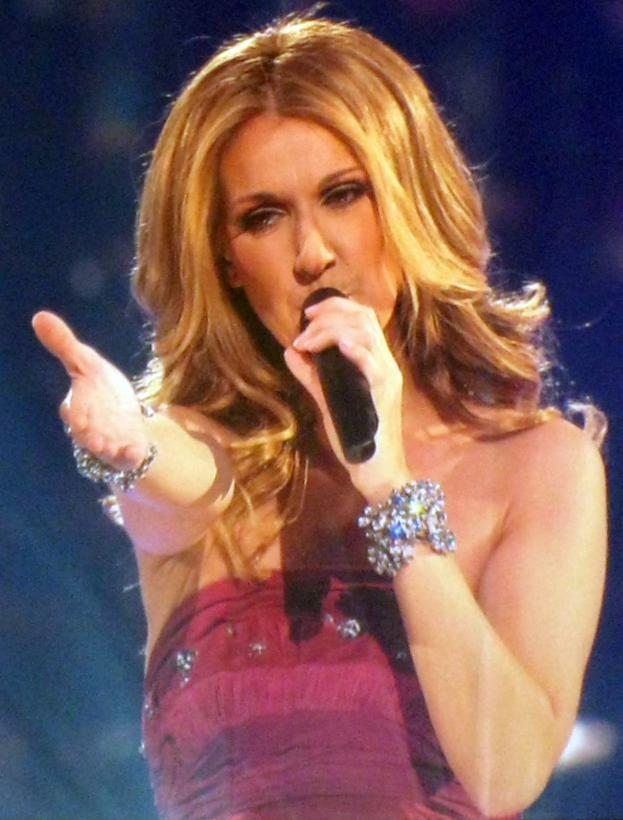

187e85024db505c19a9210e3c85192cc The Adventures of Jimmy Neutron: Boy Genius


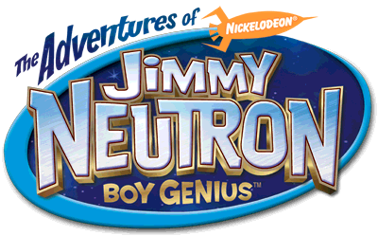

2b14596eb18bcbac89192c733b0d78c3 Jean-Guy Trudel


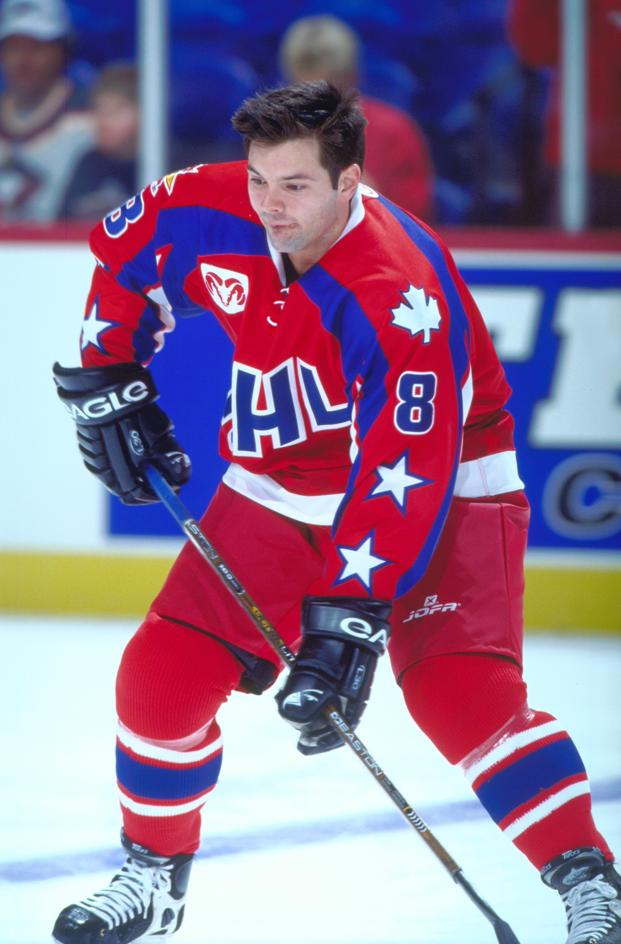

3680b1486a1eb640a4272b17222a3407 San Luis Obispo, California


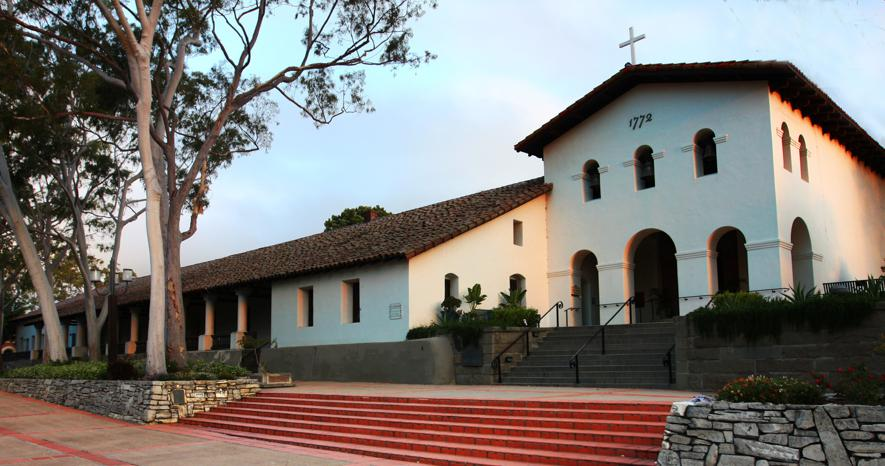

d873118799b1b8753d1b5ffbd55c8874 Oakland, California


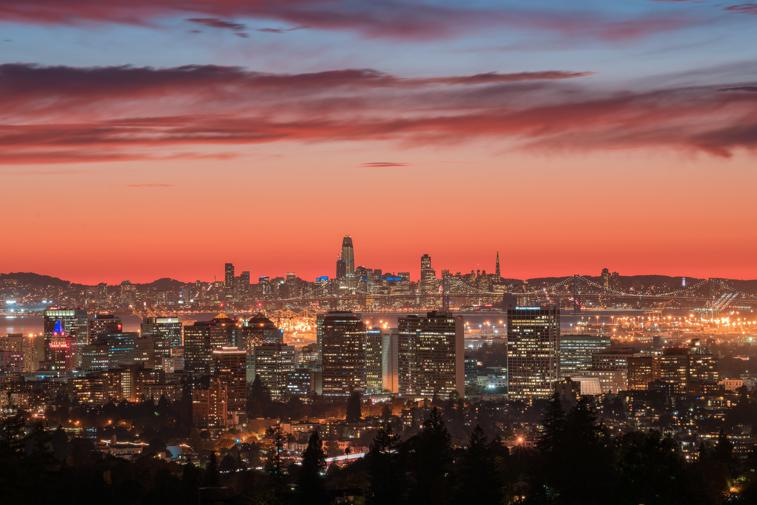

In [7]:
import json
from pathlib import Path

from IPython.display import Image as IPyImage, display

MMQA_DATA = REPO / "data" / "multimodalqa" / "dataset"
IMGS_ROOT = REPO / "data" / "multimodalqa" / "final_dataset_images"

img_files = sorted(MMQA_DATA.glob("MMQA_images_n*.jsonl"), reverse=True)
if not img_files:
    print("MMQA_images_n*.jsonl 없음:", MMQA_DATA)
elif not IMGS_ROOT.is_dir():
    print("이미지 루트 없음:", IMGS_ROOT)
else:
    path = img_files[0]
    rows = []
    with path.open(encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    print("인덱스:", path.name, "| 행:", len(rows), "| 이미지 루트:", IMGS_ROOT)
    for obj in rows[:5]:
        rel = (obj.get("path") or "").strip()
        p = IMGS_ROOT / rel if rel else None
        if not p or not p.is_file():
            print("건너뜀(파일 없음):", rel[:80])
            continue
        print(obj.get("id"), (obj.get("title") or "")[:60])
        display(IPyImage(filename=str(p), width=400))

#### MMQA 예시 — 쿼리/정답 (gold: image)



=== 쿼리 / 정답: image + 슬롯 표기(pseudo) ===
qid: 0d8f2779137fb47db953c4af5247ffe5

자연어 질문:
 What sports is the Ben Piazza 1976 movie title?

정답: baseball | answers[0].modality: image

pseudo_language_question (`[열]` 등 슬롯·참조 형식):
 What sport is  {the [Title](s) in the [Filmography] of [Ben Piazza] when the [Year] was [1976]},?

질문 metadata.modalities: ['table', 'image']
supporting_context: [{'doc_id': '8513db80c11ea439ab11eba406ec00d9', 'doc_part': 'table'}, {'doc_id': 'cadbc8e1fb23d7fe15b88ea1141d2dd2', 'doc_part': 'image'}]

정답 근거 이미지 파일: /workspace/late-interaction-mm-graph-rag/data/multimodalqa/final_dataset_images/cadbc8e1fb23d7fe15b88ea1141d2dd2.jpg


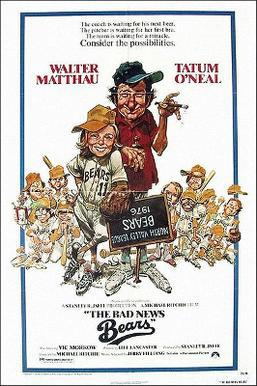

In [8]:
import json
from pathlib import Path

from IPython.display import Image as IPyImage, display

try:
    _repo = REPO
except NameError:
    _here = Path.cwd()
    _repo = _here if (_here / "config" / "model.yaml").is_file() else _here.parent

MMQA_DATA = _repo / "data" / "multimodalqa" / "dataset"
IMGS_ROOT = _repo / "data" / "multimodalqa" / "final_dataset_images"


def _first_dev_where(pred):
    dev_files = sorted(MMQA_DATA.glob("MMQA_dev_n*.jsonl"), reverse=True)
    if not dev_files:
        return None
    with dev_files[0].open(encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            o = json.loads(line)
            if pred(o):
                return o
    return None


o = _first_dev_where(lambda r: (r.get("answers") or [{}])[0].get("modality") == "image")
if not o:
    print("조건에 맞는 dev 레코드를 찾지 못했습니다.")
else:
    meta = o.get("metadata") or {}
    a0 = (o.get("answers") or [{}])[0]
    print("=== 쿼리 / 정답: image + 슬롯 표기(pseudo) ===")
    print("qid:", o.get("qid"))
    print("\n자연어 질문:\n", o.get("question"))
    print("\n정답:", a0.get("answer"), "| answers[0].modality:", a0.get("modality"))
    pl = meta.get("pseudo_language_question") or ""
    if pl:
        print("\npseudo_language_question (`[열]` 등 슬롯·참조 형식):\n", pl)
    print("\n질문 metadata.modalities:", meta.get("modalities"))
    print("supporting_context:", o.get("supporting_context"))
    img_ix = sorted(MMQA_DATA.glob("MMQA_images_n*.jsonl"), reverse=True)
    if img_ix and IMGS_ROOT.is_dir():
        want = None
        for ii in a0.get("image_instances") or []:
            if isinstance(ii, dict) and ii.get("doc_part") == "image":
                want = ii.get("doc_id")
                break
        if not want:
            for sc in o.get("supporting_context") or []:
                if sc.get("doc_part") == "image":
                    want = sc.get("doc_id")
                    break
        by_id = {}
        with img_ix[0].open(encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                obj = json.loads(line)
                by_id[obj.get("id")] = (obj.get("path") or "").strip()
        rel = by_id.get(want, "")
        p = IMGS_ROOT / rel if rel else None
        if p and p.is_file():
            print("\n정답 근거 이미지 파일:", p)
            display(IPyImage(filename=str(p), width=380))
        elif want:
            print("\n(image doc_id 있으나 로컬 파일 없음:", want, ")")


#### MMQA 예시 — 쿼리/정답 (gold: table)



In [9]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import display

try:
    _repo = REPO
except NameError:
    _here = Path.cwd()
    _repo = _here if (_here / "config" / "model.yaml").is_file() else _here.parent

MMQA_DATA = _repo / "data" / "multimodalqa" / "dataset"


def _first_dev_where(pred):
    dev_files = sorted(MMQA_DATA.glob("MMQA_dev_n*.jsonl"), reverse=True)
    if not dev_files:
        return None
    with dev_files[0].open(encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            o = json.loads(line)
            if pred(o):
                return o
    return None


o = _first_dev_where(lambda r: (r.get("answers") or [{}])[0].get("modality") == "table")
if not o:
    print("조건에 맞는 dev 레코드를 찾지 못했습니다.")
else:
    meta = o.get("metadata") or {}
    a0 = (o.get("answers") or [{}])[0]
    print("=== 쿼리 / 정답: table + 슬롯 표기(pseudo) ===")
    print("qid:", o.get("qid"))
    print("\n자연어 질문:\n", o.get("question"))
    print("\n정답:", a0.get("answer"), "| answers[0].modality:", a0.get("modality"))
    print("table_indices(행·열 인덱스):", a0.get("table_indices"))
    pl = meta.get("pseudo_language_question") or ""
    if pl:
        print("\npseudo_language_question:\n", pl)
    print("\n질문 metadata.modalities:", meta.get("modalities"))
    print("metadata.table_id:", meta.get("table_id"))
    print("supporting_context:", o.get("supporting_context"))
    tid = (meta.get("table_id") or "").strip()
    tbl_files = sorted(MMQA_DATA.glob("MMQA_tables_n*.jsonl"), reverse=True)
    gold_ri = gold_ci = None
    ti0 = (a0.get("table_indices") or [None])[0]
    if isinstance(ti0, (list, tuple)) and len(ti0) >= 2:
        gold_ri, gold_ci = int(ti0[0]), int(ti0[1])

    if not tbl_files:
        print("\nMMQA_tables_n*.jsonl 이 없습니다:", MMQA_DATA)
    elif not tid:
        print("\nmetadata.table_id 가 비어 있습니다.")
    else:
        found = False
        with tbl_files[0].open(encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                row = json.loads(line)
                if row.get("id") != tid:
                    continue
                found = True
                title = row.get("title") or ""
                t = row.get("table") or {}
                tbl_name = t.get("table_name") or ""
                tr = t.get("table_rows") or []
                hdr_list = t.get("header") or []
                col_names = [
                    (h.get("column_name") if isinstance(h, dict) else str(h))
                    for h in hdr_list
                ]
                body = []
                for rr in tr:
                    body.append(
                        [
                            (c.get("text", "") if isinstance(c, dict) else str(c))
                            for c in rr
                        ]
                    )
                if body:
                    ncols = len(body[0])
                    while len(col_names) < ncols:
                        col_names.append(f"열{len(col_names)}")
                    col_names = col_names[:ncols]
                    df = pd.DataFrame(body, columns=col_names)
                else:
                    df = pd.DataFrame()

                print("\n[MMQA_tables] 문서 제목:", title)
                print(
                    "표 이름:", tbl_name,
                    "| 데이터 행 수:", len(tr),
                    "| 열 수:", (len(col_names) if body else 0),
                )
                if gold_ri is not None and gold_ci is not None and body:
                    if 0 <= gold_ri < len(body) and 0 <= gold_ci < len(body[gold_ri]):
                        print(
                            "정답 셀 (table_indices 기준 행·열:",
                            gold_ri, ",", gold_ci, "):",
                            repr(body[gold_ri][gold_ci]),
                        )
                    else:
                        print(
                            "정답 셀 인덱스가 표 범위를 벗어남:",
                            (gold_ri, gold_ci),
                        )

                print("\n표 (정답 셀은 연한 노란색으로 강조)")
                if df.empty:
                    print("(표 본문 없음)")
                else:

                    def _highlight_answer(x):
                        styles = pd.DataFrame("", index=x.index, columns=x.columns)
                        if (
                            gold_ri is not None
                            and gold_ci is not None
                            and 0 <= gold_ri < x.shape[0]
                            and 0 <= gold_ci < x.shape[1]
                        ):
                            styles.iat[gold_ri, gold_ci] = (
                                "background-color: #fff3cd; font-weight: bold; "
                                "box-shadow: inset 0 0 0 2px #f0ad4e"
                            )
                        return styles

                    display(df.style.apply(_highlight_answer, axis=None))
                break
        if not found:
            print("\ntable_id 에 해당하는 표를 인덱스에서 찾지 못했습니다:", tid)


=== 쿼리 / 정답: table + 슬롯 표기(pseudo) ===
qid: a33985b1e8b2502fc18cc8147dc27db8

자연어 질문:
 For which film did Ben Piazza play the role of Mr. Simms?

정답: Mask | answers[0].modality: table
table_indices(행·열 인덱스): [[12, 1]]

pseudo_language_question:
 In [Filmography] of [Ben Piazza], what was the [Title](s) when the [Role] was [Mr. Simms]

질문 metadata.modalities: ['table']
metadata.table_id: 8513db80c11ea439ab11eba406ec00d9
supporting_context: [{'doc_id': '8513db80c11ea439ab11eba406ec00d9', 'doc_part': 'table'}]

[MMQA_tables] 문서 제목: Ben Piazza
표 이름: Filmography | 데이터 행 수: 16 | 열 수: 4
정답 셀 (table_indices 기준 행·열: 12 , 1 ): 'Mask'

표 (정답 셀은 연한 노란색으로 강조)


,Year,Title,Role,Notes
0,1957,A Dangerous Age,David,
1,1959,The Hanging Tree,Rune,
2,1962,No Exit,Camarero,
3,1970,"Tell Me That You Love Me, Junie Moon",Jesse,
4,1972,The Outside Man,Desk Clerk,
5,1973,The Candy Snatchers,Avery,
6,1976,The Bad News Bears,Bob Whitewood,
7,1977,I Never Promised You a Rose Garden,Jay Blake,
8,1979,Nightwing,Roger Piggott,
9,1979,The Concorde ... Airport '79,Associate,"TV version, Uncredited"


#### MMQA 예시 — 쿼리/정답 (gold: text)



In [18]:
import json
from pathlib import Path

try:
    _repo = REPO
except NameError:
    _here = Path.cwd()
    _repo = _here if (_here / "config" / "model.yaml").is_file() else _here.parent

MMQA_DATA = _repo / "data" / "multimodalqa" / "dataset"


def _first_dev_where(pred):
    dev_files = sorted(MMQA_DATA.glob("MMQA_dev_n*.jsonl"), reverse=True)
    if not dev_files:
        return None
    with dev_files[0].open(encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            o = json.loads(line)
            if pred(o):
                return o
    return None


def _load_text_doc(doc_id):
    if not doc_id:
        return None
    tfiles = sorted(MMQA_DATA.glob("MMQA_texts_n*.jsonl"), reverse=True)
    if not tfiles:
        return None
    with tfiles[0].open(encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            row = json.loads(line)
            if row.get("id") == doc_id:
                return row
    return None


o = _first_dev_where(lambda r: (r.get("answers") or [{}])[0].get("modality") == "text")
if not o:
    print("조건에 맞는 dev 레코드를 찾지 못했습니다.")
else:
    meta = o.get("metadata") or {}
    a0 = (o.get("answers") or [{}])[0]
    print("=== 쿼리 / 정답: text + 슬롯 표기(pseudo) ===")
    print("qid:", o.get("qid"))
    print("\n자연어 질문:\n", o.get("question"))
    print("\n정답:", a0.get("answer"), "| answers[0].modality:", a0.get("modality"))
    pl = meta.get("pseudo_language_question") or ""
    if pl:
        print("\npseudo_language_question:\n", pl)
    print("\n질문 metadata.modalities:", meta.get("modalities"))
    print("supporting_context:", o.get("supporting_context"))
    tins = a0.get("text_instances") or []
    print("answers[0].text_instances:", tins)
    if tins:
        did = tins[0].get("doc_id") if isinstance(tins[0], dict) else None
        doc = _load_text_doc(did)
        if doc:
            tx = doc.get("text") or ""
            snippet = tx[:520] + ("…" if len(tx) > 520 else "")
            print("\n지원 텍스트 문서 제목:", doc.get("title"))
            print("일부 발췌 (MMQA_texts):\n", snippet)


=== 쿼리 / 정답: text + 슬롯 표기(pseudo) ===
qid: 710a6d2254076ea58756c6c7cc211f1e

자연어 질문:
 When was the movie that had Ben Piazza in the role of Bob Whitewood released?

정답: 1976 | answers[0].modality: text

pseudo_language_question:
 when did  {the [Title](s) in the [Filmography] of [Ben Piazza] when the [Role] was [Bob Whitewood]}, come out

질문 metadata.modalities: ['table', 'text']
supporting_context: [{'doc_id': '8513db80c11ea439ab11eba406ec00d9', 'doc_part': 'table'}, {'doc_id': '5346073795a986f7bbbacbd4b197a787', 'doc_part': 'text'}]
answers[0].text_instances: [{'doc_id': '5346073795a986f7bbbacbd4b197a787', 'part': 'text', 'start_byte': 24, 'text': '1976'}]

지원 텍스트 문서 제목: The Bad News Bears
일부 발췌 (MMQA_texts):
 The Bad News Bears is a 1976 American sports comedy film directed by Michael Ritchie. It stars Walter Matthau and Tatum O'Neal. The film was followed by two sequels, The Bad News Bears in Breaking Training in 1977 and The Bad News Bears Go to Japan in 1978, a short-lived 1979–8

## MMQA 산출물 위치

실행 후 `result/multimodalqa/<RUN_ID 하위폴더>/`에 다음이 생깁니다:

- `mmqa_slice/` — MMQA 질문·텍스트·이미지·테이블을 표준 파일명으로 둔 **실행용 번들** (`mmqa_questions.jsonl`, `mmqa_texts.jsonl`, `mmqa_images.jsonl`, `mmqa_tables.jsonl`)
- `phase2_pattern_cache/`, `phase3_extraction_cache/`
- `phase4_graphs_out/*.graphml`
- `phase5_inference/predictions.json`, `evaluation_report.json`

In [10]:
import datetime
from pathlib import Path

mmqa_root = REPO / "result" / "multimodalqa"
if mmqa_root.is_dir():
    runs = sorted(mmqa_root.iterdir(), key=lambda p: p.stat().st_mtime, reverse=True)
    for p in runs[:8]:
        ts = datetime.datetime.fromtimestamp(p.stat().st_mtime)
        pred = (p / "phase5_inference" / "predictions.json").is_file()
        rep = (p / "phase5_inference" / "evaluation_report.json").is_file()
        print(p.name, "| mtime:", ts.isoformat(sep=" ", timespec="seconds"))
        print("    predictions:", pred, "| evaluation_report:", rep)
else:
    print("result/multimodalqa 없음")

20260512_142100_mmqa_manual | mtime: 2026-05-12 05:14:52
    predictions: False | evaluation_report: False
20260511_142339_n2 | mtime: 2026-05-11 14:29:02
    predictions: True | evaluation_report: True
20260511_planAB_test_n5 | mtime: 2026-05-11 09:10:14
    predictions: True | evaluation_report: True
20260511_080917_n5 | mtime: 2026-05-11 08:28:35
    predictions: True | evaluation_report: True


## GraphML 하나 살펴보기

WebQA 튜토리얼과 동일하게 `result/**/phase4_graphs_out/*.graphml` 중 하나를 읽어 통계·spring layout 미리보기를 합니다.

file: result/multimodalqa/20260511_142339_n2/phase4_graphs_out/710a6d2254076ea58756c6c7cc211f1e_graph.graphml
nodes: 16   edges: 9
density (undirected): 0.075000
 sample node: WHY ME? Bt: MOVIE {'entity_name': 'Why Me?', 'type': 'Movie', 'description': 'A 1990 American caper comedy film\nIs based on a book series', 'source_id': '710a6d2254076ea58756c6c7cc211f1e_5a01f1debd370ba4417d5d1efeee7816, 710a6d2254076ea58756c6c7cc211f1e_b3048808d8fc1c00a22f3a0fd3f17f10', 'doc_id': '5a01f1debd370ba4417d5d1efeee7816, b3048808d8fc1c00a22f3a0fd3f17f10'}
 sample node: GENE QUINTANO Bt: PERSON {'entity_name': 'Gene Quintano', 'type': 'Person', 'description': 'Director of Why Me?', 'source_id': '710a6d2254076ea58756c6c7cc211f1e_5a01f1debd370ba4417d5d1efeee7816, 710a6d2254076ea58756c6c7cc211f1e_b3048808d8fc1c00a22f3a0fd3f17f10', 'doc_id': '5a01f1debd370ba4417d5d1efeee7816, b3048808d8fc1c00a22f3a0fd3f17f10'}
 sample node: CHRISTOPHER LAMBERT Bt: PERSON {'entity_name': 'Christopher Lambert', 'type': 'Pers

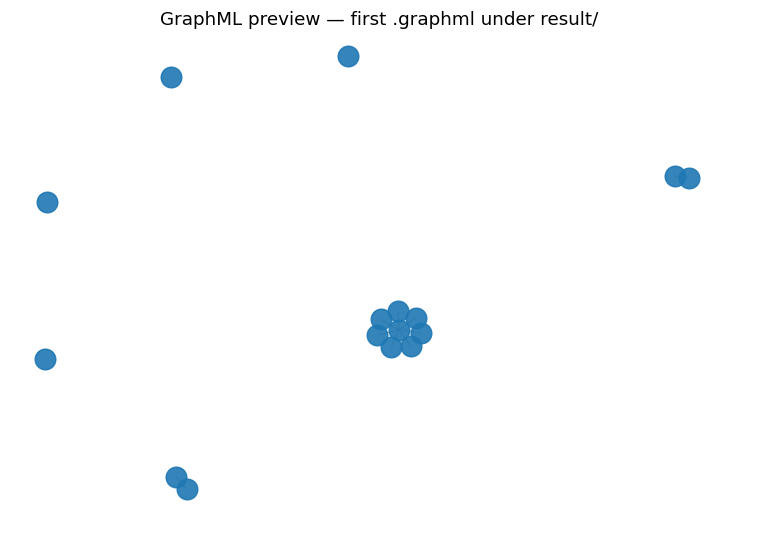

In [11]:
import matplotlib.pyplot as plt
import networkx as nx

graphs_dir = REPO / "result"
gml_files = list(graphs_dir.glob("**/phase4_graphs_out/*.graphml"))
if not gml_files:
    print("GraphML 없음 (result/**/phase4_graphs_out/)")
else:
    path = sorted(gml_files)[0]
    G = nx.read_graphml(path)
    print("file:", path.relative_to(REPO))
    print("nodes:", G.number_of_nodes(), "  edges:", G.number_of_edges())
    try:
        _Gu = G.to_undirected() if G.is_directed() else G
        print("density (undirected):", f"{nx.density(_Gu):.6f}")
    except Exception as _e:
        print("density skipped:", _e)
    for nid in list(G.nodes)[:3]:
        print(" sample node:", nid, dict(G.nodes[nid]))

    _G = G.to_undirected() if G.is_directed() else G
    _n = _G.number_of_nodes()
    if _n == 0:
        pass
    elif _n > 300:
        print("plot skipped: too many nodes (", _n, ")")
    else:
        fig, ax = plt.subplots(figsize=(7, 5), dpi=110)
        k = 0.6 / max(1, _n ** 0.5)
        pos = nx.spring_layout(_G, seed=0, k=k, iterations=50)
        nx.draw_networkx(
            _G,
            pos=pos,
            ax=ax,
            with_labels=False,
            node_size=180,
            width=0.6,
            edge_color="gray",
            alpha=0.9,
        )
        ax.set_title("GraphML preview — first .graphml under result/")
        ax.axis("off")
        fig.tight_layout()
        plt.show()

## 단계별 실행(수동)

`RUN_ID`는 `multimodalqa/<실험명>`처럼 접두사 포함을 권장합니다. `N_QUERIES`, `DRY_RUN`을 바꾼 뒤 순서대로 실행하세요.

한 번에 실행을 이미 돌렸다면 여기서는 새 RUN_ID를 쓰거나 이 절을 건너뜁니다.

In [12]:
import os
import subprocess
import sys
from pathlib import Path

from util.llm_defaults import DEFAULT_GEMMA4_E4B_IT_MODEL_PATH

# --- 실험에서 바꿀 값 ---
RUN_ID = "multimodalqa/20260512_142100_mmqa_manual"
# slice(mmqa_slice/)와 별개: pattern~inference에서 처리할 질문 수 상한
N_QUERIES = 2
DRY_RUN = False

MMQA_DATA_DIR = REPO / "data" / "multimodalqa" / "dataset"
MMQA_IMGS = REPO / "data" / "multimodalqa" / "final_dataset_images"

result_dir = REPO / "result" / RUN_ID
slice_dir = result_dir / "mmqa_slice"
q_file = slice_dir / "mmqa_questions.jsonl"
t_file = slice_dir / "mmqa_texts.jsonl"

dry_run = "1" if DRY_RUN else "0"
gemma_path = os.environ.get("GEMMA4_E4B_IT_MODEL_PATH", "").strip() or str(DEFAULT_GEMMA4_E4B_IT_MODEL_PATH)

common_env = {
    "PYTHONPATH": str(REPO),
    "MMGRAPHRAG_RUN_ID": RUN_ID,
    "MMGRAPHRAG_DATASET": "mmqa",
    "WEBQA_RUN_PROFILE": "val_n100",
    "WEBQA_DATA_ROOT": str(REPO / "data" / "webqa"),
    "MMQA_DATA_DIR": str(MMQA_DATA_DIR),
    "PATTERN_MAX_SAMPLES": str(N_QUERIES),
    "WEBQA_EXPORT_MAX": str(N_QUERIES),
    "EXTRACTION_MAX_QUESTIONS": str(N_QUERIES),
    "CONSTRUCT_MAX_QUESTIONS": str(N_QUERIES),
    "INFERENCE_MAX_QUESTIONS": str(N_QUERIES),
    "PATTERN_DRY_RUN": dry_run,
    "EXTRACTION_DRY_RUN": dry_run,
    "PATTERN_CONCURRENCY": "1",
    "EXTRACTION_CONCURRENCY": "1",
    "GEMMA4_E4B_IT_MODEL_PATH": gemma_path,
    "VIDORE_TEXT_LLM_BACKEND": "hf_gemma_4_e4b_it",
    "COLEMBED_MODEL_PATH": os.environ.get(
        "COLEMBED_MODEL_PATH",
        str(REPO / "models" / "retriever" / "llama-nemotron-colembed-vl-3b-v2"),
    ),
}


def run_step(desc: str, cmd: list[str], env: dict) -> int:
    merged = {**os.environ, **env}
    print(f"\n=== {desc} ===\n{' '.join(cmd)}\n")
    r = subprocess.run(cmd, cwd=str(REPO), env=merged)
    print(f"종료 코드={r.returncode}")
    return r.returncode


if os.environ.get("GEMMA4_E4B_IT_TORCH_DTYPE"):
    common_env["GEMMA4_E4B_IT_TORCH_DTYPE"] = os.environ["GEMMA4_E4B_IT_TORCH_DTYPE"]
elif not DRY_RUN:
    common_env.setdefault("GEMMA4_E4B_IT_TORCH_DTYPE", "bf16")

if DRY_RUN:
    common_env["MMGRAPHRAG_STRICT_REAL"] = "0"

print("RUN_ID:", RUN_ID, "| N_QUERIES:", N_QUERIES, "| DRY_RUN:", DRY_RUN)
print("MMQA_DATA_DIR:", MMQA_DATA_DIR)
print("MMQA 이미지 루트:", MMQA_IMGS)
print("결과:", result_dir)
print("mmqa_slice (실행용 MMQA 번들, export 대상):", slice_dir)
print("Gemma:", gemma_path)
print("ColEmbed:", common_env.get("COLEMBED_MODEL_PATH"))

RUN_ID: multimodalqa/20260512_142100_mmqa_manual | N_QUERIES: 2 | DRY_RUN: False
MMQA_DATA_DIR: /workspace/late-interaction-mm-graph-rag/data/multimodalqa/dataset
MMQA 이미지 루트: /workspace/late-interaction-mm-graph-rag/data/multimodalqa/final_dataset_images
결과: /workspace/late-interaction-mm-graph-rag/result/multimodalqa/20260512_142100_mmqa_manual
mmqa_slice (실행용 MMQA 번들, export 대상): /workspace/late-interaction-mm-graph-rag/result/multimodalqa/20260512_142100_mmqa_manual/mmqa_slice
Gemma: /workspace/late-interaction-mm-graph-rag/models/mllm/gemma-4-E4B-it
ColEmbed: /workspace/late-interaction-mm-graph-rag/models/retriever/llama-nemotron-colembed-vl-3b-v2


### 0단계 — `export_mmqa_slice.py`

이 노트북에서 **slice**(`mmqa_slice/`)는 MMQA 원본 JSONL 묶음을 이번 run에서 쓰기 좋은 고정 파일명으로 복사·정규화한 **실행용 데이터 폴더**입니다.

입력 — `data/multimodalqa/dataset/` (`MMQA_SPLIT` 기본 `dev`):

- `MMQA_dev_n*.jsonl` (또는 선택한 split의 `MMQA_<split>_n*.jsonl`) — 질문
- `MMQA_texts_n*.jsonl`, `MMQA_images_n*.jsonl`, `MMQA_tables_n*.jsonl` — 맥락

출력 — `MMQA_SLICE_DIR`(아래 셀에서는 `result/<RUN_ID>/mmqa_slice/`):

- `mmqa_questions.jsonl`, `mmqa_texts.jsonl`, `mmqa_images.jsonl`, `mmqa_tables.jsonl`

`MMQA_SLICE_DIR`로 출력 위치를 고정합니다. 위 shard 파일들이 있어야 합니다.

**참고:** `N_QUERIES` 같은 값은 slice의 의미가 아니라, 이후 pattern / extraction / construct / inference에서 **몇 개 질문만 처리할지**를 줄이는 실행 설정에 가깝습니다.


In [13]:
import sys
from pathlib import Path

# mmqa_slice/: 실행용 MMQA 번들(질문·텍스트·이미지·테이블 JSONL 표준명) 생성
result_dir.mkdir(parents=True, exist_ok=True)
if slice_dir.exists():
    import shutil

    shutil.rmtree(slice_dir)

export_env = {**common_env, "MMQA_SLICE_DIR": str(slice_dir)}
_rc0 = run_step("0단계 MMQA export", [sys.executable, "export_mmqa_slice.py"], export_env)
if _rc0 != 0:
    print("경고: export 실패")

_qpath = slice_dir / "mmqa_questions.jsonl"
if _qpath.is_file():
    _nq = sum(1 for _ in _qpath.open(encoding="utf-8"))
    print("슬라이스 질문 줄 수:", _nq)
else:
    print("mmqa_questions.jsonl 없음")


=== 0단계 MMQA export ===
/workspace/late-interaction-mm-graph-rag/.venv/bin/python export_mmqa_slice.py

[session] log_file=/workspace/late-interaction-mm-graph-rag/logs/20260513_094058_export_mmqa_slice.log
Wrote 100 questions, 925 texts, 257 images, 30 tables → /workspace/late-interaction-mm-graph-rag/result/multimodalqa/20260512_142100_mmqa_manual/mmqa_slice
종료 코드=0
슬라이스 질문 줄 수: 100


### 패턴 (`pattern.py`)

패턴은 [Query-Driven Multimodal GraphRAG (Bu et al., ACL 2025 Findings)](https://aclanthology.org/2025.findings-acl.1100/)에서 말하는 것처럼, 질의 의미에 맞춰 동적으로 잡히는 부분 그래프 골격입니다. 이 단계에서 LLM이 질문별로 어떤 노드·관계 타입을 우선할지 정하고, 다음 추출 단계가 그 설계도에 맞춰 증거를 채웁니다.

- **Pattern cache**는 질문마다 만들어지는 **그래프 설계도**입니다. 입력은 MMQA **question 텍스트**이고, LLM이 풀이에 필요한 **엔티티 타입·관계 타입**을 추론합니다(예: Ben Piazza가 특정 역할로 출연한 영화의 개봉 시점을 묻는 질문이면 `Movie`, `Person`, `Role`, `Date`와 `has_actor`, `played_role`, `released_on` 등이 될 수 있음).
- 결과는 **`phase2_pattern_cache/{qid}.json`**에 저장되며, **extraction**에서 텍스트·테이블·이미지 근거를 **어떤 구조로 추출할지** 잡아 주는 **constraint**로 쓰입니다.
- 따라서 이 cache는 **정답이 아니라**, graph construction을 위한 **query-driven schema**(질의 주도 스키마)에 가깝습니다.


In [14]:
# pattern.py가 각 질문에 대해 사용하는 프롬프트 템플릿: `prompt.GRAPH_PATTERN_PROMPT`
# `{question}` 자리에 MMQA `question` 필드 문자열이 치환됩니다 (`pattern.process_batch`).

from prompt import GRAPH_PATTERN_PROMPT

print("GRAPH_PATTERN_PROMPT — pattern.py의 LLM 입력 템플릿\n")
print(GRAPH_PATTERN_PROMPT)


GRAPH_PATTERN_PROMPT — pattern.py의 LLM 입력 템플릿

-Goal-
Given a question, generate a compact graph pattern for downstream relation extraction.

-Steps-
1. Identify a small set of likely entity types relevant to the question.
2. Identify possible relation patterns connecting these entity types.
3. Return output in the exact required format:
   - First block: a Python-style list of entity types
   - Then one or more relation pattern blocks separated by `##`
   - End each relation block with `<|COMPLETE|>`
4. Do not add explanation text.

Output format:
["TYPE_1", "TYPE_2", ...]##TYPE_1 <|> relation_name <|> TYPE_2<|COMPLETE|>##TYPE_2 <|> relation_name <|> TYPE_3<|COMPLETE|>

######################
-Real Data-
######################
Question: {question}
Output:


In [24]:
pattern_cache = result_dir / "phase2_pattern_cache"
pattern_env = {
    **common_env,
    "PATTERN_JSON_FILE_PATH": str(q_file),
    "PATTERN_CACHE_DIR": str(pattern_cache),
}
_rc_p2 = run_step("2단계 패턴", [sys.executable, "pattern.py"], pattern_env)
print("패턴 캐시:", pattern_cache, "| 존재:", pattern_cache.is_dir())


=== 2단계 패턴 ===
/workspace/late-interaction-mm-graph-rag/.venv/bin/python pattern.py



[session] log_file=/workspace/late-interaction-mm-graph-rag/logs/20260512_053222_pattern.log
종료 코드=0
패턴 캐시: /workspace/late-interaction-mm-graph-rag/result/multimodalqa/20260512_142100_mmqa_manual/phase2_pattern_cache | 존재: True


### 패턴 캐시 내용 보기

`phase2_pattern_cache/*.json`에는 질문별 LLM 패턴 응답(`response`)과 원본 질문(`question`)이 저장됩니다. 아래 셀에서 파일 목록과 요약을 출력합니다.


In [ ]:
import json

def _pattern_entry_parts(data: dict) -> tuple[str, str, str]:
    q = data.get("question") or {}
    if "qid" in q:
        qid, qtext = q["qid"], q.get("question", "")
    else:
        qid, qtext = q.get("Guid", ""), q.get("Q", "")
    resp = data.get("response", "")
    return str(qid), str(qtext).replace("\n", " "), str(resp).replace("\n", " ")


def _short(s: str, n: int) -> str:
    s = s.strip()
    return s if len(s) <= n else s[: n - 3] + "..."


if not pattern_cache.is_dir():
    print("(디렉터리 없음)", pattern_cache)
else:
    files = sorted(pattern_cache.glob("*.json"))
    print(f"JSON 파일 수: {len(files)}  |  경로: {pattern_cache}\n")
    for fp in files:
        with fp.open(encoding="utf-8") as f:
            row = json.load(f)
        qid, qtxt, resp = _pattern_entry_parts(row)
        print("---", fp.name)
        print("  qid:", qid)
        print("  question:", _short(qtxt, 200))
        print("  response:", _short(resp, 280))


### 추출 (`extraction.py`)

In [ ]:
extraction_cache = result_dir / "phase3_extraction_cache"
extraction_env = {
    **common_env,
    "EXTRACTION_QUESTION_FILE": str(q_file),
    "EXTRACTION_TEXT_FILE": str(t_file),
    "EXTRACTION_PATTERN_CACHE_DIR": str(pattern_cache),
    "EXTRACTION_CACHE_DIR": str(extraction_cache),
}
_rc_p3 = run_step("3단계 추출", [sys.executable, "extraction.py"], extraction_env)
print("추출 캐시:", extraction_cache, "| 존재:", extraction_cache.is_dir())

### GraphML 구성 (`construct.py`)

In [ ]:
graph_dir = result_dir / "phase4_graphs_out"
construct_env = {
    **common_env,
    "CONSTRUCT_SLICE_DIR": str(slice_dir),
    "CONSTRUCT_QUESTION_FILE": str(q_file),
    "CONSTRUCT_TABLE_FILE": str(slice_dir / "mmqa_tables.jsonl"),
    "CONSTRUCT_IMAGE_FILE": str(slice_dir / "mmqa_images.jsonl"),
    "CONSTRUCT_TEXT_FILE": str(t_file),
    "CONSTRUCT_EXTRACTION_CACHE": str(extraction_cache),
    "CONSTRUCT_OUTPUT_GRAPH_DIR": str(graph_dir),
    "CONSTRUCT_WEBQA_SLICE_DIR": str(slice_dir),
}
_rc_p4 = run_step("4단계 그래프 구성", [sys.executable, "construct.py"], construct_env)
_gml_list = list(graph_dir.glob("*.graphml")) if graph_dir.is_dir() else []
print("GraphML 개수:", len(_gml_list), "| dir:", graph_dir)

### 추론 (`inference.py`)

`MMGRAPHRAG_DATASET=mmqa`일 때 이미지 루트는 `MMQA_IMAGES_DIR`로 넘깁니다.

In [ ]:
import os

phase5_dir = result_dir / "phase5_inference"
phase5_dir.mkdir(parents=True, exist_ok=True)
pred_json = phase5_dir / "predictions.json"

inference_env = {
    **common_env,
    "INFERENCE_GRAPH_DIR": str(graph_dir),
    "INFERENCE_QUESTION_FILE": str(q_file),
    "INFERENCE_OUTPUT_JSON": str(pred_json),
    "INFERENCE_MAX_QUESTIONS": str(N_QUERIES),
    "INFERENCE_DRY_RUN": dry_run,
    "INFERENCE_COLEMBED_RETRIEVAL": os.environ.get("INFERENCE_COLEMBED_RETRIEVAL", "1"),
    "INFERENCE_SLICE_DIR": str(slice_dir),
    "INFERENCE_WEBQA_SLICE_DIR": str(slice_dir),
    "MMQA_IMAGES_DIR": str(MMQA_IMGS if MMQA_IMGS.is_dir() else Path(os.getenv("MMQA_IMAGES_DIR", str(MMQA_IMGS)))),
}
_rc_p5 = run_step("5단계 추론", [sys.executable, "inference.py"], inference_env)

if pred_json.is_file():
    import json as _json

    with pred_json.open(encoding="utf-8") as _f:
        _preds = _json.load(_f)
    _keys = list(_preds.keys()) if isinstance(_preds, dict) else []
    print("\n예측 qid 수:", len(_keys))
    for _qid in _keys[:5]:
        print(f"  qid={_qid}:", str(_preds[_qid])[:240]!r})
else:
    print("추론 출력 없음:", pred_json)

### QA 평가 (`eval/evaluate_multimodal_qa.py`)

MMQA도 동일 스크립트로 골드 `mmqa_questions.jsonl`과 예측을 비교합니다. `--split_label`만 실험에 맞게 바꿉니다.

In [ ]:
import json
import sys
from pathlib import Path


def _print_mmqa_report_summary_kr(report_path: Path) -> None:
    def _f(x) -> float:
        try:
            if x is None:
                return 0.0
            return float(x)
        except (TypeError, ValueError):
            return 0.0

    if not report_path.is_file():
        print("평가 리포트 없음:", report_path)
        return
    with report_path.open(encoding="utf-8") as f:
        rep = json.load(f)
    counts = rep.get("counts") or {}
    print("\n" + "=" * 62)
    print("MMQA QA 평가 요약 (evaluate_multimodal_qa.py)")
    print("=" * 62)
    print(
        "샘플 — 전체:",
        counts.get("All"),
        "| 채점된 qid:",
        counts.get("scored"),
        "| 단일모달:",
        counts.get("Unimodal"),
        "| 멀티모달:",
        counts.get("Multimodal"),
    )
    lb = rep.get("leaderboard_summary") or {}
    labels = {"All": "전체", "Unimodal": "단일모달", "Multimodal": "멀티모달"}
    for bucket in ("All", "Unimodal", "Multimodal"):
        b = lb.get(bucket) or {}
        if not b:
            continue
        print(
            f"  [{labels[bucket]}]  QA-FL={_f(b.get('QA-FL')):.4f}  "
            f"QA-Acc={_f(b.get('QA-Acc')):.4f}  QA={_f(b.get('QA')):.4f}"
        )
    scores = rep.get("scores") or {}
    all_s = scores.get("All") or {}
    if all_s:
        print(
            "원시 list F1 / list EM:",
            f"{_f(all_s.get('f1')):.4f}",
            "/",
            f"{_f(all_s.get('em')):.4f}",
        )
    print("상세:", report_path.resolve())
    print("=" * 62 + "\n")


if pred_json.is_file():
    report_json = phase5_dir / "evaluation_report.json"
    split_label = f"mmqa_dev_n{N_QUERIES}"
    _rc_p6 = run_step(
        "6단계 평가",
        [
            sys.executable,
            "eval/evaluate_multimodal_qa.py",
            "--predictions",
            str(pred_json),
            "--gold_jsonl",
            str(q_file),
            "--report_json",
            str(report_json),
            "--split_label",
            split_label,
        ],
        {**common_env, "MMGRAPHRAG_RUN_ID": RUN_ID},
    )
    if _rc_p6 == 0:
        _print_mmqa_report_summary_kr(report_json)
    else:
        print("평가 비정상 종료:", _rc_p6)
else:
    print("평가 건너뜀: predictions.json 없음")

## 부록: 터미널

- 통합: `python tests/test_pipeline.py --dataset mmqa -n 5 [--dry-run]`
- 쉘 스크립트: `bash scripts/mmqa_pipeline_n.sh 5` (`MMGRAPHRAG_DATASET=mmqa` 등 설정 포함)

단계별 환경 변수 전체는 `tests/test_pipeline.py`를 참고합니다.

## 데모 UI(선택)

`demo/be/config/paths.yaml`에서 MMQA `run_id`·슬라이스·이미지 경로를 맞추면 WebQA와 같이 플레이그라운드를 쓸 수 있습니다. 자세한 내용은 `demo/README.md`.


### 데모 백엔드 구조와 API

**구성 관계:** `demo/be/server.py`가 FastAPI 앱을 만들고, **시작 시(lifespan)** `config/resolve_demo_paths.py`로 `result/<RUN>/`를 읽은 뒤 **`services/`**의 `RunService`, `QuestionService`, `GraphService`, `ImageService`, `LLMService`(및 Ollama용 래퍼) 등을 만들어 **`application.state`**에 둡니다. **`routers/`**의 각 파일은 URL만 정의하고, 핸들러 안에서 `request.app.state`의 서비스를 꺼내 **JSONL·GraphML·이미지 파일**을 읽거나 챗 응답을 만듭니다.

**요청 흐름:** 브라우저의 FE → `http://127.0.0.1:8000/api/...` → **router** → **service** → 디스크 산출물. (`pattern.py` / `inference.py` 파이프라인과는 **별 프로세스**이며, 이미 쌓인 결과를 **읽기 전용**으로 보여 줍니다.)

**대표 REST API** (BE 기본 `8000`, 상세·변경은 `demo/be/README.md`)

| 메서드 | 경로 | 비고 |
|--------|------|------|
| GET | `/health` | 상태 + 기본 WebQA `run_id` |
| GET | `/docs` | Swagger |
| GET | `/api/datasets` | `webqa` / `mmqa` 로드 여부 |
| GET | `/api/run/info` | 쿼리 `dataset=webqa` 또는 `mmqa` |
| GET | `/api/run/scores` | 동일 |
| GET | `/api/questions` | 동일 |
| GET | `/api/questions/{qid}` | 동일 |
| GET | `/api/graphs/{qid}` | 노드/엣지 JSON |
| GET | `/api/graphs/{qid}/graphml` | GraphML 파일 |
| GET | `/api/images` | 이미지 id 목록, 선택 `limit` |
| GET | `/api/images/{image_id}` | 이미지 바이너리 |
| POST | `/api/chat` | 본문 JSON: `question`(필수), `dataset`, `model`(HF/Ollama 선택) |


### 노트북에서 데모 BE + FE 시작

WebQA 튜토리얼과 동일한 셀: `REPO` 정의 후 백그라운드로 `demo/be/server.py`와 `demo/fe` Vite를 띄웁니다.

In [ ]:
import os
import shutil
import subprocess
import sys
import time
from pathlib import Path

try:
    _repo = REPO
except NameError:
    _here = Path.cwd()
    _repo = _here if (_here / "demo" / "be" / "server.py").is_file() else _here.parent

be_dir = _repo / "demo" / "be"
fe_dir = _repo / "demo" / "fe"
if not (be_dir / "server.py").is_file():
    raise FileNotFoundError(f"데모 백엔드 없음: {be_dir}")

if "DEMO_PROCESSES" not in globals():
    DEMO_PROCESSES = []
else:
    for _p in list(DEMO_PROCESSES):
        if _p.poll() is None:
            _p.terminate()
    DEMO_PROCESSES.clear()

BE_PORT = int(os.environ.get("DEMO_BE_PORT", "8000"))
FE_PORT = int(os.environ.get("DEMO_FE_PORT", "5173"))

be_env = {**os.environ, "PYTHONPATH": str(be_dir)}
p_be = subprocess.Popen(
    [sys.executable, "server.py", "--host", "0.0.0.0", "--port", str(BE_PORT)],
    cwd=str(be_dir),
    env=be_env,
    stdin=subprocess.DEVNULL,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
    start_new_session=True,
)
DEMO_PROCESSES.append(p_be)
print(f"데모 BE 시작 | pid={p_be.pid} | http://127.0.0.1:{BE_PORT}/health")
time.sleep(1.5)

npm = shutil.which("npm")
if npm is None:
    print("npm 없음 — Node 설치 후 demo/fe에서 npm install && npm run dev")
else:
    if not (fe_dir / "node_modules").is_dir():
        print("demo/fe npm install …")
        subprocess.run([npm, "install"], cwd=str(fe_dir), check=False)
    p_fe = subprocess.Popen(
        [npm, "run", "dev"],
        cwd=str(fe_dir),
        env={**os.environ},
        stdin=subprocess.DEVNULL,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
        start_new_session=True,
    )
    DEMO_PROCESSES.append(p_fe)
    print(f"데모 FE 시작 | pid={p_fe.pid} | http://127.0.0.1:{FE_PORT}/")

print("\n중지는 다음 셀.")

### 데모 서버 중지

In [ ]:
import time as _time

if "DEMO_PROCESSES" in globals() and DEMO_PROCESSES:
    for _p in DEMO_PROCESSES:
        if _p.poll() is None:
            _p.terminate()
    _time.sleep(0.5)
    for _p in DEMO_PROCESSES:
        if _p.poll() is None:
            _p.kill()
    DEMO_PROCESSES.clear()
    print("데모 프로세스 종료.")
else:
    print("DEMO_PROCESSES 없음.")

## 더 읽을 거리

- `README.md`
- `notebook/colgraphrag_webqa_pipeline_tutorial_kor.ipynb` — WebQA 대응 튜토리얼
- `tests/test_pipeline.py`, `scripts/mmqa_pipeline_n.sh`

## 처음부터 끝까지 한 번에 실행

`tests/test_pipeline.py --dataset mmqa`가 Phase 0(export)부터 평가까지 묶습니다.

- `-n 5` — 질문 상한 (패턴/추출/구성/추론 모두 동일 캡).
- `--dry-run` — LLM·ColEmbed 실호출 없이 배선 확인( CUDA 미사용 ).
- 실추론 시 `--dry-run` 제거 및 GPU 필요.

터미널에서 동일: `bash scripts/mmqa_pipeline_n.sh 5` (실모델 고정 스크립트).

In [ ]:
import os
import subprocess
import sys

DRY_RUN = False
N_QUERIES = 5

env = os.environ.copy()
env["PYTHONPATH"] = str(REPO)
if not DRY_RUN:
    env.setdefault("GEMMA4_E4B_IT_TORCH_DTYPE", "bf16")

cmd = [
    sys.executable,
    str(REPO / "tests" / "test_pipeline.py"),
    "--dataset",
    "mmqa",
    "-n",
    str(N_QUERIES),
]
if DRY_RUN:
    cmd.append("--dry-run")

print("설정 DRY_RUN=", DRY_RUN, " N_QUERIES=", N_QUERIES)
print("실행:", " ".join(cmd))
r = subprocess.run(cmd, cwd=str(REPO), env=env)
print("종료 코드:", r.returncode)

print("\n--- 최근 multimodalqa 실행(참고) ---")
_root = REPO / "result" / "multimodalqa"
if _root.is_dir():
    subs = sorted(_root.iterdir(), key=lambda p: p.stat().st_mtime, reverse=True)
    for p in subs[:5]:
        pred = (p / "phase5_inference" / "predictions.json").is_file()
        rep = (p / "phase5_inference" / "evaluation_report.json").is_file()
        print(f"  {p.name}  |  predictions={pred}  evaluation_report={rep}")
else:
    print("  result/multimodalqa/ 아직 없음")

설정 DRY_RUN= False  N_QUERIES= 2
실행: /workspace/late-interaction-mm-graph-rag/.venv/bin/python /workspace/late-interaction-mm-graph-rag/tests/test_pipeline.py --dataset mmqa -n 2
GraphRAG pipeline test
Session log: /workspace/late-interaction-mm-graph-rag/logs/20260511_142339_test_pipeline_multimodalqa_20260511_142339_n2.log
Dataset: mmqa
Run ID: multimodalqa/20260511_142339_n2
Result dir: /workspace/late-interaction-mm-graph-rag/result/multimodalqa/20260511_142339_n2
Queries (cap): 2
MMQA data dir: /workspace/late-interaction-mm-graph-rag/data/multimodalqa/dataset
MMQA: prebuilt slice=(export_mmqa_slice)
Mode: real Gemma + ColEmbed (MMGRAPHRAG_STRICT_REAL=1)
[INFO] CUDA device: NVIDIA RTX A6000

[PHASE 0] MMQA slice → mmqa_slice

[Export MMQA slice]
CMD: /workspace/late-interaction-mm-graph-rag/.venv/bin/python export_mmqa_slice.py
CWD: /workspace/late-interaction-mm-graph-rag

[session] log_file=/workspace/late-interaction-mm-graph-rag/logs/20260511_142353_export_mmqa_slice.log
Wrote 

Loading weights: 100%|██████████| 2076/2076 [00:55<00:00, 37.67it/s] 


[OK] Pattern extraction completed successfully
[INFO] Pattern cache: 2 files

[PHASE 3] Knowledge extraction

[Knowledge extraction]
CMD: /workspace/late-interaction-mm-graph-rag/.venv/bin/python extraction.py
CWD: /workspace/late-interaction-mm-graph-rag

[session] log_file=/workspace/late-interaction-mm-graph-rag/logs/20260511_142550_extraction.log


Loading weights: 100%|██████████| 2076/2076 [00:04<00:00, 434.36it/s]
